In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

In [230]:
df = pd.read_csv("/content/Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [231]:
print(df.isnull().sum())

CustomerID            0
Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64


In [232]:
le = LabelEncoder()
df["Genre"] = le.fit_transform(df["Genre"])

In [233]:
X = df[["Annual_Income_(k$)", "Spending_Score"]]

In [234]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


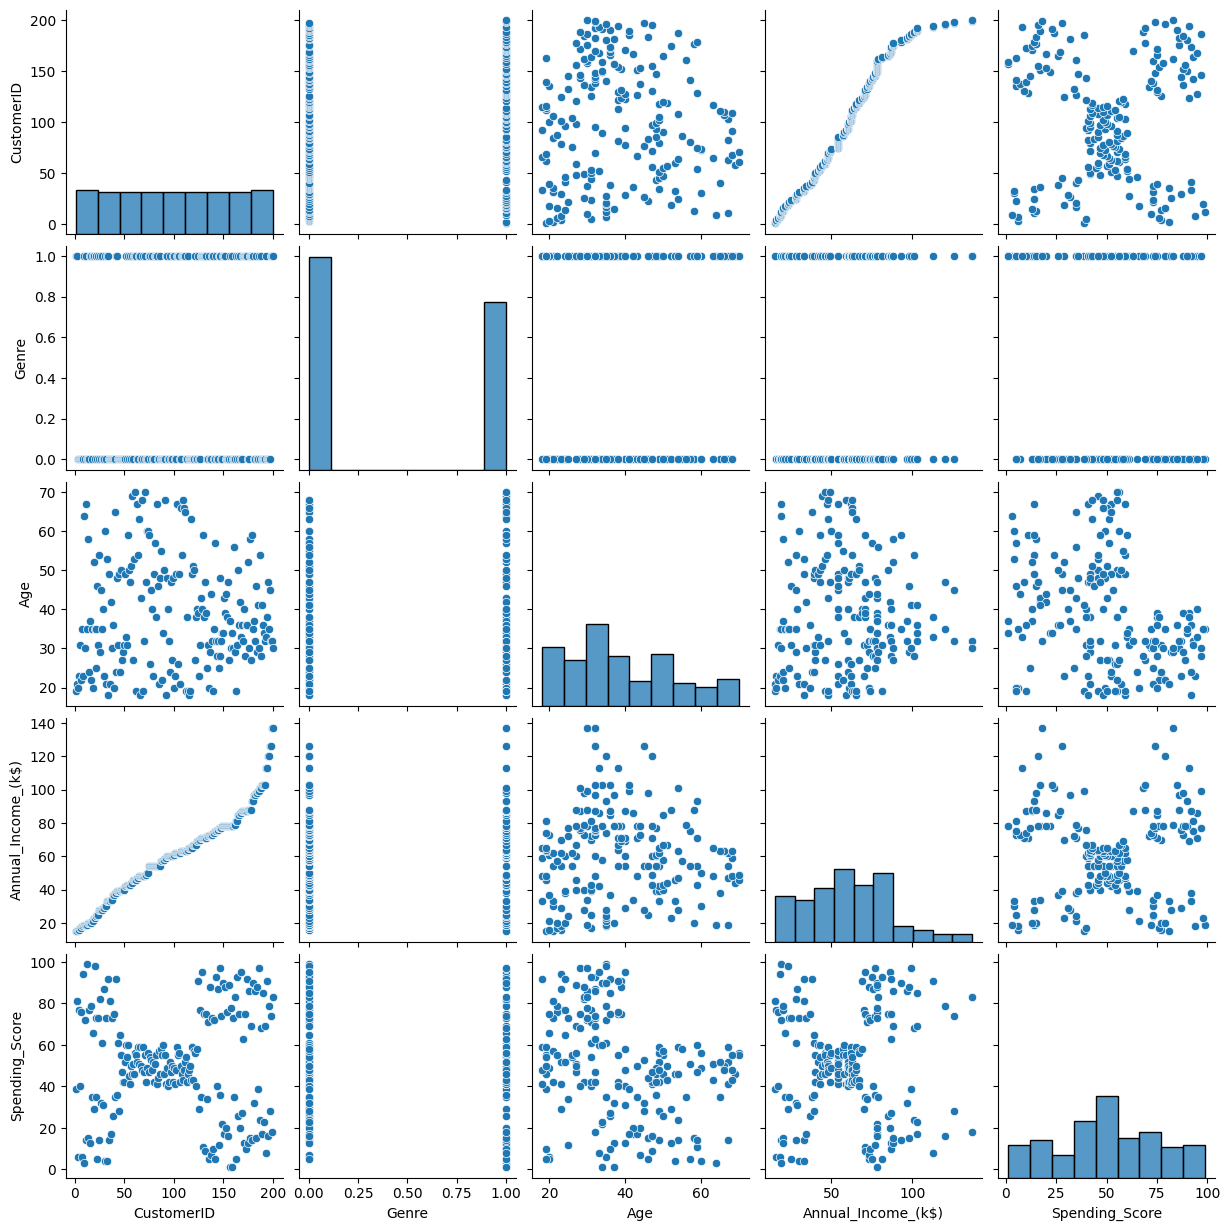

In [235]:
sns.pairplot(df)

In [236]:
q=df.iloc[:,3:].values
q

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [237]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=9, min_samples=4,metric='euclidean')

In [238]:
model=db.fit(q)

In [239]:
label=model.labels_

In [240]:
label

array([ 2,  0,  1,  0,  2,  0,  1, -1,  1,  0,  1, -1,  1,  0,  1,  0,  2,
        0,  2, -1,  2,  0,  1,  0,  1,  0,  2,  0,  2,  0,  1,  0,  1,  0,
        1,  0,  1,  0,  3,  0,  3, -1,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  4,  3,  4,  3,  4,  5,  4,  5,  4,  3,  4,  5,  4,
        5,  4,  5,  4,  5,  4,  3,  4,  5,  4,  3,  4,  5,  4,  5,  4,  5,
        4,  5,  4,  5,  4,  5,  4,  3,  4,  5,  4,  5,  4,  5,  4,  5,  4,
        5,  4,  5,  4,  5,  4,  5,  4,  5,  4,  6,  4,  5,  4, -1, -1,  6,
       -1,  6,  4,  6, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [241]:
np.sum(label == -1)

np.int64(16)

In [243]:

n_clusters = len(set(label)) - (1 if -1 in label else 0)

print("Number of Clusters:", n_clusters)

# Add labels to dataframe
df["Cluster"] = label

print(df.head())

Number of Clusters: 7
   CustomerID  Genre  Age  Annual_Income_(k$)  Spending_Score  Cluster
0           1      1   19                  15              39        2
1           2      1   21                  15              81        0
2           3      0   20                  16               6        1
3           4      0   23                  16              77        0
4           5      0   31                  17              40        2


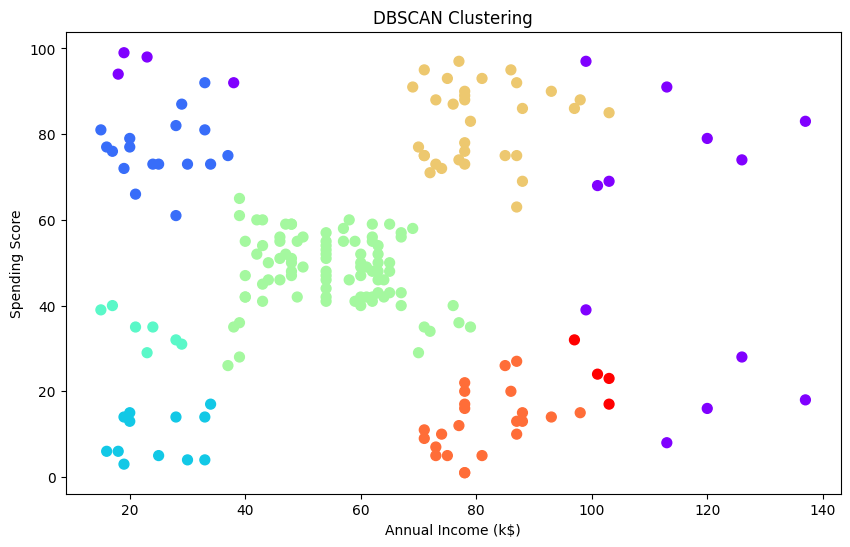

In [244]:
plt.figure(figsize=(10,6))

plt.scatter(
    q[:,0],
    q[:,1],
    c=label,
    cmap='rainbow',
    s=50
)

plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

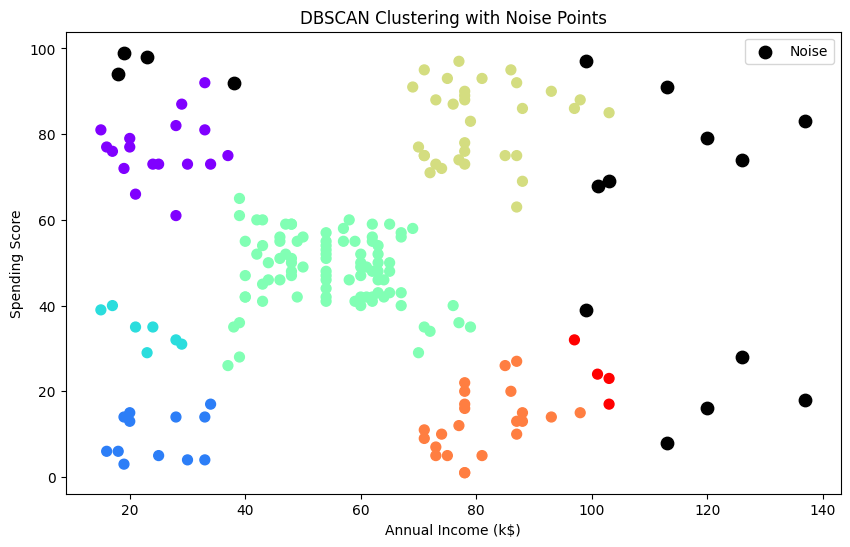

In [245]:
plt.figure(figsize=(10,6))
plt.scatter(
    q[label != -1, 0],
    q[label != -1, 1],
    c=label[label != -1],
    cmap='rainbow',
    s=50
)
plt.scatter(
    q[label == -1, 0],
    q[label == -1, 1],
    color='black',
    label='Noise',
    s=80
)

plt.title("DBSCAN Clustering with Noise Points")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.show()